In [26]:
import numpy as np

## Load Preprocessed Data

In [1]:
from preprocessing import preprocess
X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(feature_method="hog", n_pca=50,balance=True)


Loading MNIST dataset...
Split completed: Train=10660, Val=1185, Test=10000


## testing pca's separability

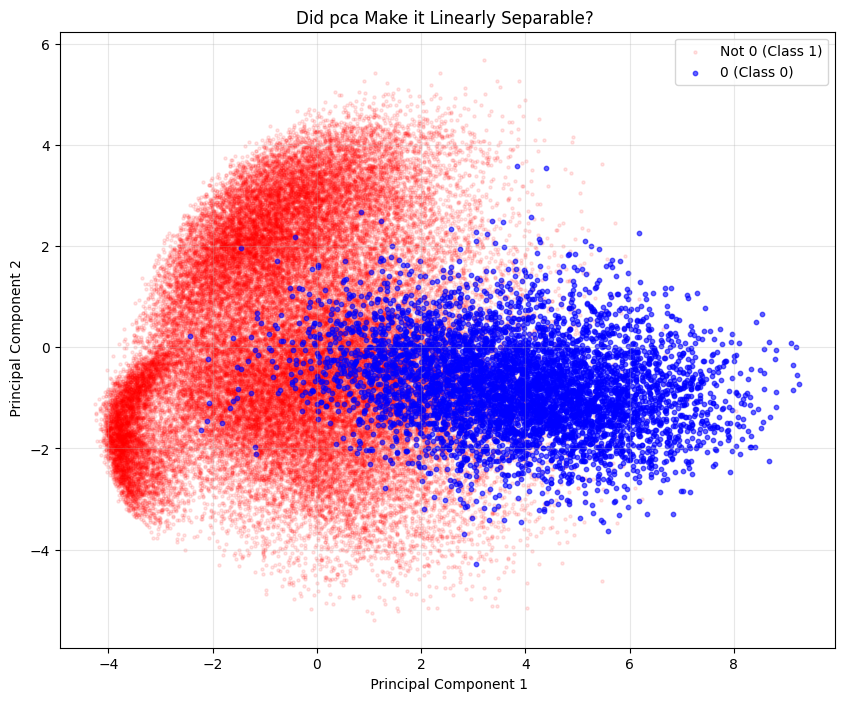

In [25]:
from preprocessing import CustomPCA

import matplotlib.pyplot as plt



def plot_pca_separability(X_data, y_data):
    
    # 1. Initialize our custom PCA for exactly 2 components
    pca_2d = CustomPCA(n_components=2)
    
    # 2. Fit and transform the HOG training data
    X_2d = pca_2d.fit_transform(X_data)
    
    # 3. Separate coordinates by class
    zeros_x = X_2d[y_data == 0, 0]
    zeros_y = X_2d[y_data == 0, 1]
    
    not_zeros_x = X_2d[y_data == 1, 0]
    not_zeros_y = X_2d[y_data == 1, 1]
    
    # 4. Generate the Scatter Plot
    plt.figure(figsize=(10, 8))
    
    # Plot 'Not 0' first so it sits in the background
    plt.scatter(not_zeros_x, not_zeros_y, color='red', label='Not 0 (Class 1)', alpha=0.1, s=5)
    # Plot '0' on top
    plt.scatter(zeros_x, zeros_y, color='blue', label='0 (Class 0)', alpha=0.6, s=10)
    
    plt.title("Did pca Make it Linearly Separable? ")
    plt.xlabel(" Principal Component 1")
    plt.ylabel(" Principal Component 2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run the visualization on the HOG training set
plot_pca_separability(X_train, y_train)

In [23]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Initialize the scout model USING YOUR WEIGHTS
# We pass your custom class weights to balance the 10% vs 90% split
scout = LinearSVC(max_iter=2000, dual=False, class_weight=weights)

print("Training the scout model on HOG features with class weights...")
scout.fit(X_train, y_train)

# 2. Comprehensive Training Metrics (Linear Separability Check)
train_preds = scout.predict(X_train)
print("\n" + "="*45)
print("  TRAINING PERFORMANCE (Separability Test)")
print("="*45)
print(classification_report(y_train, train_preds, target_names=["0 (Class 0)", "Not 0 (Class 1)"]))

# 3. Comprehensive Validation Metrics (Generalization Check)
val_preds = scout.predict(X_val)
print("\n" + "="*45)
print("  VALIDATION PERFORMANCE (Generalization Test)")
print("="*45)
print(classification_report(y_val, val_preds, target_names=["0 (Class 0)", "Not 0 (Class 1)"]))

# 4. The Confusion Matrix
print("\nValidation Confusion Matrix:")
conf_matrix = confusion_matrix(y_val, val_preds)
print(f"True '0's found:      {conf_matrix[0][0]} | False 'Not 0's (Missed 0s): {conf_matrix[0][1]}")
print(f"False '0's (Accidents): {conf_matrix[1][0]}  | True 'Not 0's found:    {conf_matrix[1][1]}")

Training the scout model on HOG features with class weights...

  TRAINING PERFORMANCE (Separability Test)
                 precision    recall  f1-score   support

    0 (Class 0)       0.90      0.99      0.94      5336
Not 0 (Class 1)       1.00      0.99      0.99     48664

       accuracy                           0.99     54000
      macro avg       0.95      0.99      0.97     54000
   weighted avg       0.99      0.99      0.99     54000


  VALIDATION PERFORMANCE (Generalization Test)
                 precision    recall  f1-score   support

    0 (Class 0)       0.90      0.97      0.94       587
Not 0 (Class 1)       1.00      0.99      0.99      5413

       accuracy                           0.99      6000
      macro avg       0.95      0.98      0.96      6000
   weighted avg       0.99      0.99      0.99      6000


Validation Confusion Matrix:
True '0's found:      572 | False 'Not 0's (Missed 0s): 15
False '0's (Accidents): 64  | True 'Not 0's found:    5349


In [2]:
import numpy as np

class CustomLinearSVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):

        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters        
        self.w = None
        self.b = None

    def fit(self, X, y):
        
        n_samples, n_features = X.shape
        
        self.w = np.zeros(n_features)
        self.b = 0.0
        
        y_mirrored = np.where(y <= 0, -1, 1)

        for epoch in range(self.n_iters):
            
            for idx, x_i in enumerate(X):
                
                y_i = y_mirrored[idx]
                f_i= np.dot((self.w).T, x_i)+self.b

                if f_i * y_i <1:
                    self.w=self.w-self.lr*(self.lambda_param*self.w - y_i*x_i)
                    self.b = self.b + self.lr * y_i
                
                else:
                    self.w=self.w-self.lr*self.lambda_param*self.w 

                
              

    def predict(self, X):
       linear_output = np.dot(X, self.w) + self.b
       prediction = np.where(linear_output >= 0, 1, 0)
       return prediction
       


## Training

In [3]:
import time
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Initialize YOUR custom model 
# We dropped n_iters to 50 for the first run so you aren't waiting forever!
print("Initializing Custom Linear SVM...")
custom_svm = CustomLinearSVM(learning_rate=0.001, lambda_param=0.01, n_iters=50)

# 2. Fit the model and time it
print("Training the custom model... (This might take a minute or two in pure Python!)")
start_time = time.time()
custom_svm.fit(X_train, y_train)  # Make sure X_train is your HOG data!
print(f"Training completed in {(time.time() - start_time):.2f} seconds.")

# 3. Predict and evaluate on Validation Set
print("\nEvaluating on Validation Data...")
val_preds = custom_svm.predict(X_val)

# 4. Metrics
print("\n" + "="*45)
print("  CUSTOM MODEL VALIDATION PERFORMANCE")
print("="*45)
print(classification_report(y_val, val_preds, target_names=["0 (Class 0)", "Not 0 (Class 1)"]))

conf_matrix = confusion_matrix(y_val, val_preds)
print("\nValidation Confusion Matrix:")
print(f"True '0's found:      {conf_matrix[0][0]} | False 'Not 0's (Missed 0s): {conf_matrix[0][1]}")
print(f"False '0's (Accidents): {conf_matrix[1][0]}  | True 'Not 0's found:    {conf_matrix[1][1]}")

Initializing Custom Linear SVM...
Training the custom model... (This might take a minute or two in pure Python!)
Training completed in 4.20 seconds.

Evaluating on Validation Data...

  CUSTOM MODEL VALIDATION PERFORMANCE
                 precision    recall  f1-score   support

    0 (Class 0)       0.98      0.98      0.98       584
Not 0 (Class 1)       0.98      0.98      0.98       601

       accuracy                           0.98      1185
      macro avg       0.98      0.98      0.98      1185
   weighted avg       0.98      0.98      0.98      1185


Validation Confusion Matrix:
True '0's found:      573 | False 'Not 0's (Missed 0s): 11
False '0's (Accidents): 10  | True 'Not 0's found:    591
